In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import random
from collections import namedtuple

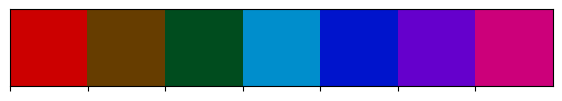

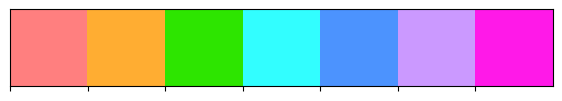

In [2]:
import os
import sys
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.policy_analysis import discount_episode_reward

In [3]:
log_dir = "../models/9_9/Penalty/q_learning/env_0.0/eps_1.0/q_lr_0.001/reward_lr_0.001/"
train_reward = np.load(log_dir + "/training_joint_reward_1.npy", allow_pickle=True)[()]

In [6]:
ep_rewards, _ = discount_episode_reward(train_reward, gamma=0.99)

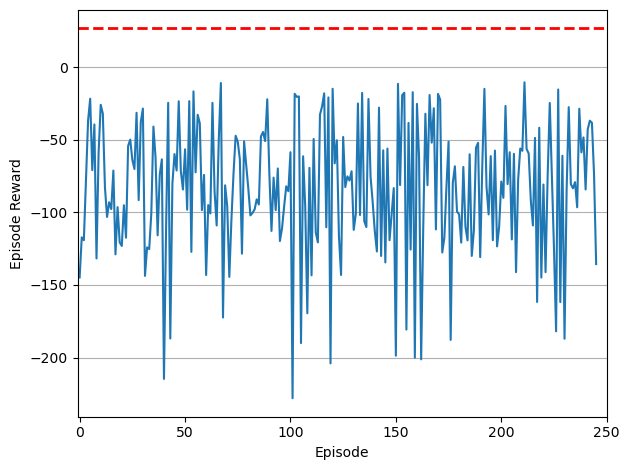

In [21]:
plt.plot(ep_rewards)
plt.hlines(0.99 * 27, -1, 251, lw=2, color="r", linestyles="--")
plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.grid(axis="y")
plt.xlim(-1, 250)
plt.tight_layout()

In [42]:
policy_net = torch.load(log_dir + "/q_network_best").eval()
reward_net = torch.load(log_dir + "/reward_network_best").eval()
buffer = np.load(log_dir + "/replay_buffer.npy", allow_pickle=True)[()]

In [37]:
Transition = namedtuple("Transition", ("obs", "action", "next_obs", "reward"))
device = "mps:0"
def process_batch(batch):
    batch = Transition(*zip(*batch))
    real_reward_mask = [not np.isnan(p) for p in [r["mdp"] for r in batch.reward]]
    if len(real_reward_mask) == 0:
        raise ValueError("All nan")
    non_final_mask = torch.tensor(tuple(map(lambda s: s["mdp"] is not None, batch.next_obs)), dtype=torch.bool)
    non_final_next_states = torch.tensor([s["mdp"] for s in batch.next_obs if s["mdp"] is not None], device=device, dtype=torch.float)

    real_reward_idx = [i for i, x in enumerate(real_reward_mask) if x]
    mdp_obs = torch.tensor([state["mdp"] for state in batch.obs], device=device, dtype=torch.float)[real_reward_idx]
    mon_obs = torch.tensor([state["monitor"] for state in batch.obs], device=device, dtype=torch.float)[real_reward_idx]

    # mdp_next_obs = torch.tensor([next_state["mdp"] for next_state in batch.next_obs])[real_reward_idx]
    # mon_next_obs = torch.tensor([next_state["monitor"] for next_state in batch.next_obs])[real_reward_idx]

    mdp_reward = torch.tensor([reward["mdp"] for reward in batch.reward], device=device, dtype=torch.float)[real_reward_idx]
    mon_reward = torch.tensor([reward["monitor"] for reward in batch.reward], device=device, dtype=torch.float)[real_reward_idx]

    mdp_action = torch.tensor([a["mdp"] for a in batch.action], device=device)[real_reward_idx]
    mon_action = torch.tensor([a["monitor"] for a in batch.action], device=device)[real_reward_idx]

    return mdp_obs, mon_obs.unsqueeze(1), non_final_mask, non_final_next_states, mdp_reward.unsqueeze(1), mon_reward.unsqueeze(1), mdp_action.unsqueeze(1), mon_action.unsqueeze(1)

In [38]:
samples = random.sample(list(buffer), 512)
mdp_obs, mon_obs, non_final_mask, non_final_next_states, mdp_reward, mon_reward, mdp_action, mon_action = process_batch(samples)

In [49]:
point = 22
print(mdp_obs[point, 0])
print("action {}, reward {}".format(mdp_action[point, 0].item(), mdp_reward[point, 0].item()))
print("Q values", np.round(policy_net(mdp_obs[point].unsqueeze(0)).detach().cpu().numpy()[0], 3))
print("Reward values", np.round(reward_net(mdp_obs[point].unsqueeze(0)).detach().cpu().numpy()[0], 3))

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0')
action 0, reward 0.0
Q values [ 0.176 -9.715  0.375 -9.837]
Reward values [  0.033 -10.149  -0.142 -10.164]
